In [76]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate

from datasets import load_dataset
from utils.func import read_jsonl, softmax
from utils.metric import evaluate

model_name = "LLaVA-7B"
fix = "_oe"
data = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")
len(data)

0it [00:00, ?it/s]

1000

In [77]:
dataset = load_dataset("AI4Math/MathVista", split='testmini')
len(dataset)

1000

In [78]:
if not os.path.exists(f"./output/{model_name}/MathV{fix}_output.json"):
    res = {}
    for pid in range(len(dataset)):
        dic = dataset[pid]
        del dic['decoded_image']
        dic['response'] = data[pid]['response']
        res[pid+1] = dic

    json.dump(res, open(f"./output/{model_name}/MathV{fix}_output.json", 'w'))

In [79]:
print(f"""python extract_answer.py \\
    --output_dir "../../TowardsTrustworthy/output/{model_name}/" \\
    --output_file "MathV{fix}_output.json" \\
    --llm_engine "gpt-4-0125-preview" """)

python extract_answer.py \
    --output_dir "../../TowardsTrustworthy/output/LLaVA-7B/" \
    --output_file "MathV_oe_output.json" \
    --llm_engine "gpt-4-0125-preview" 


In [80]:
print(f"""python calculate_score.py \\
    --output_dir "/data/qinyu/research/TowardsTrustworthy/output/{model_name}/" \\
    --output_file "MathV{fix}_output.json" """)

python calculate_score.py \
    --output_dir "/data/qinyu/research/TowardsTrustworthy/output/LLaVA-7B/" \
    --output_file "MathV_oe_output.json" 


### Please evaluate the results use the codes provided by the MathVista repo
After that, you can run the following codes

In [81]:
data = json.load(open(f"./output/{model_name}/MathV{fix}_output.json"))
logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")

0it [00:00, ?it/s]

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score
from scipy.special import softmax
import numpy as np

X = np.array([ins['logits'] for ins in logits])
# y = np.array([1 if data[str(i)]["true_false"] else 0 for i in range(1, 1001)])

y = np.array([
    1 if str(data[str(i)]["response"]).strip() == str(data[str(i)]["answer"]).strip() else 0
    for i in range(1, 1001)
])
model = LogisticRegression()
res = cross_validate(model, X, y, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(res['test_roc_auc'])
print(res['test_accuracy'])
print(res['test_f1'])

print(f"AUROC: {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC: {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1: {np.mean(res['test_f1'])*100:.2f}")

y_probs = cross_val_predict(model, X, y, cv=10, method='predict_proba')[:, 1]


[0.76302083 0.83854167 0.93229167 0.59635417 0.84895833 0.66145833
 0.74739583 0.75368421 0.83578947 0.47157895]
[0.96 0.93 0.97 0.95 0.95 0.91 0.92 0.95 0.94 0.91]
[0.5        0.         0.4        0.         0.28571429 0.
 0.         0.28571429 0.25       0.        ]
AUROC: 74.49
ACC: 93.90
F1: 17.21


Please use the LVLMs to self-evaluate their solutions, and run the following codes

In [75]:
data = json.load(open(f"./output/{model_name}/MathV{fix}_output.json"))
logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")

X = np.array([ins['logits'] for ins in logits])
# y = np.array([1 if data[str(i)]["true_false"] else 0 for i in range(1, 1001)])
y = np.array([
    1 if str(data[str(i)]["response"]).strip() == str(data[str(i)]["answer"]).strip() else 0
    for i in range(1, 1001)
])

model = LogisticRegression()
res = cross_validate(model, X, y, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(res['test_roc_auc'])
print(res['test_accuracy'])
print(res['test_f1'])

print(f"AUROC: {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC: {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1: {np.mean(res['test_f1'])*100:.2f}")


0it [00:00, ?it/s]

[0.76302083 0.83854167 0.93229167 0.59635417 0.84895833 0.66145833
 0.74739583 0.75368421 0.83578947 0.47157895]
[0.96 0.93 0.97 0.95 0.95 0.91 0.92 0.95 0.94 0.91]
[0.5        0.         0.4        0.         0.28571429 0.
 0.         0.28571429 0.25       0.        ]
AUROC: 74.49
ACC: 93.90
F1: 17.21


## Bar chart of average metrics

In [56]:
data = json.load(open(f"./output/{model_name}/MathV{fix}_output.json"))
logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")

X = np.array([ins['logits'] for ins in logits])
# y = np.array([1 if data[str(i)]["true_false"] else 0 for i in range(1, 1001)])
y = np.array([
    1 if str(data[str(i)]["response"]).strip() == str(data[str(i)]["answer"]).strip() else 0
    for i in range(1, 1001)
])

model = LogisticRegression(class_weight='balanced')
res = cross_validate(model, X, y, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(res['test_roc_auc'])
print(res['test_accuracy'])
print(res['test_f1'])

print(f"AUROC: {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC: {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1: {np.mean(res['test_f1'])*100:.2f}")


0it [00:00, ?it/s]

[0.7826087  0.83559783 0.92119565 0.85190217 0.71331522 0.84737485
 0.8021978  0.70940171 0.90598291 0.73626374]
[0.88 0.9  0.89 0.92 0.9  0.9  0.92 0.86 0.92 0.9 ]
[0.33333333 0.44444444 0.26666667 0.42857143 0.44444444 0.5
 0.42857143 0.3        0.55555556 0.28571429]
AUROC: 81.06
ACC: 89.90
F1: 39.87


In [ ]:
# finetune
model = LogisticRegression(max_iter=1000)
model.fit(X, y)
# default prediction
default_pred = model.predict(X)
# custom threshold 0.7
y_proba = model.predict_proba(X)[:, 1]
custom_pred = (y_proba >= 0.7).astype(int)
print("ACC @0.7:", accuracy_score(y, custom_pred))
print("F1 @0.7:", f1_score(y, custom_pred))

ACC @0.7: 1.0
F1 @0.7: 1.0


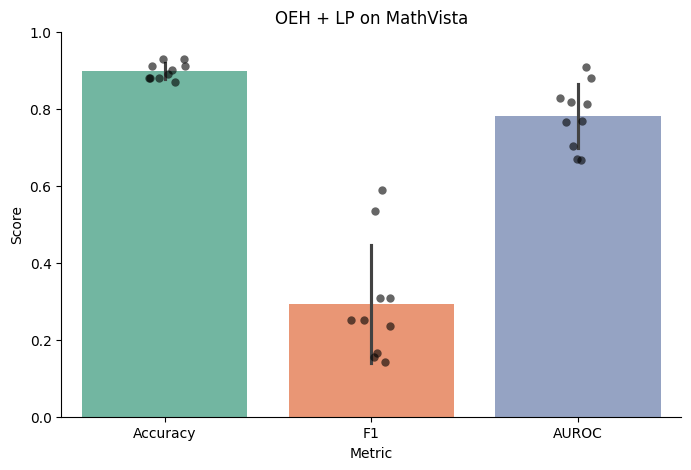

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Extract actual metrics from cross-validation results
df = pd.DataFrame({
    "Accuracy": res['test_accuracy'],
    "F1": res['test_f1'],
    "AUROC": res['test_roc_auc']
})

# Melt into long format for Seaborn
df_melt = df.melt(var_name="Metric", value_name="Score")

plt.figure(figsize=(8,5))
sns.barplot(data=df_melt, x="Metric", y="Score", palette="Set2", ci="sd")
sns.stripplot(data=df_melt, x="Metric", y="Score", color="black", size=6, jitter=True, alpha=0.6)
plt.title("OEH + LP on MathVista")
plt.ylabel("Score")
plt.ylim(0, 1)  # since sklearn metrics are between 0–1
sns.despine()
plt.show()

## Confusion matrix from trained model

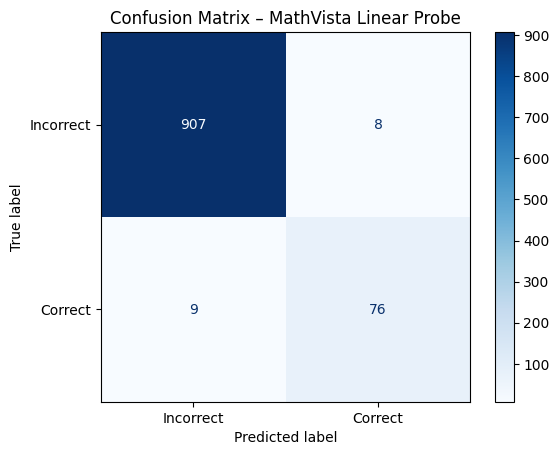

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Train on all data (or last fold) to get predictions
model.fit(X, y)
y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Incorrect","Correct"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – MathVista Linear Probe")
plt.show()


## ROC Curve (using trained model)

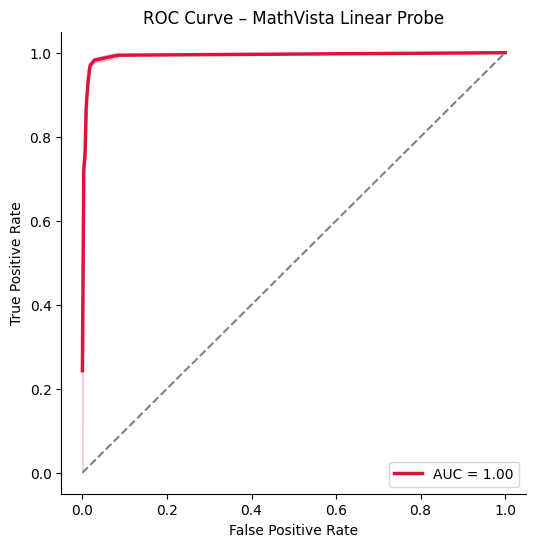

In [20]:
from sklearn.metrics import roc_curve, auc

y_scores = model.predict_proba(X)[:,1]  # probability for class 1
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.2f}", linewidth=2.5, color="crimson")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MathVista Linear Probe")
plt.legend(loc="lower right")
sns.despine()
plt.show()


In [29]:
import json
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# Path to your self-eval file
file_path = "./output/LLaVA-7B/MathV_self_eval.jsonl"

labels = []
scores = []

# Load JSONL file
with open(file_path) as f:
    for line in f:
        ins = json.loads(line)
        
        # Ground truth: if label is "Unanswerable" treat as 0, otherwise 1
        # (adjust depending on your dataset convention)
        gt = 0 if str(ins["label"]).lower() in ["unanswerable", "0"] else 1
        
        # Model response: float from string
        try:
            pred = float(str(ins["response"]).strip().split()[0])
        except:
            pred = 0.0  # fallback if parsing fails
        
        labels.append(gt)
        scores.append(pred)

labels = np.array(labels)
scores = np.array(scores)

# Binarize predictions with threshold 0.5
preds = (scores >= 0.5).astype(int)

# Compute metrics
auroc = roc_auc_score(labels, scores)
acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds)

print(f"AUROC: {auroc*100:.2f}")
print(f"ACC: {acc*100:.2f}")
print(f"F1: {f1*100:.2f}")


AUROC: 59.60
ACC: 77.70
F1: 87.32


In [31]:
import json
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# Path to your self-eval file
file_path = "./output/LLaVA-7B/MathV_oeh.jsonl"

labels = []
scores = []

# Load JSONL file
with open(file_path) as f:
    for line in f:
        ins = json.loads(line)
        
        # Ground truth: if label is "Unanswerable" treat as 0, otherwise 1
        # (adjust depending on your dataset convention)
        gt = 0 if str(ins["label"]).lower() in ["unanswerable", "0"] else 1
        
        # Model response: float from string
        try:
            pred = float(str(ins["response"]).strip().split()[0])
        except:
            pred = 0.0  # fallback if parsing fails
        
        labels.append(gt)
        scores.append(pred)

labels = np.array(labels)
scores = np.array(scores)

# Binarize predictions with threshold 0.5
preds = (scores >= 0.5).astype(int)

# Compute metrics
auroc = roc_auc_score(labels, scores)
acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds)

print(f"AUROC: {auroc*100:.2f}")
print(f"ACC: {acc*100:.2f}")
print(f"F1: {f1*100:.2f}")


AUROC: 41.84
ACC: 36.10
F1: 52.42


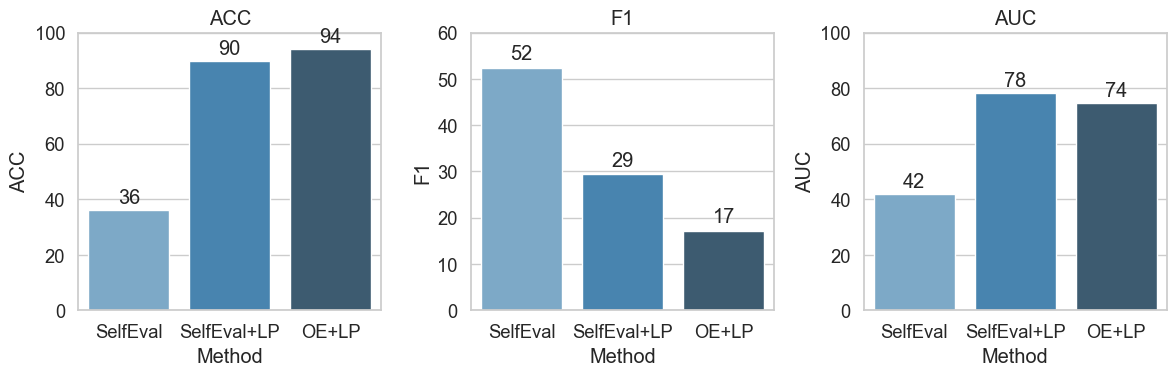

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your results
data = {
    "Method": ["SelfEval", "SelfEval+LP", "OE+LP"],
    "ACC": [36.10, 89.80, 93.90],
    "F1": [52.42, 29.36, 17.21],
    "AUC": [41.84, 78.15, 74.49],
}

df = pd.DataFrame(data)

# Plot style
sns.set(style="whitegrid", font_scale=1.2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# ACC plot
sns.barplot(ax=axes[0], x="Method", y="ACC", data=df, palette="Blues_d")
for idx, val in enumerate(df["ACC"]):
    axes[0].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[0].set_ylim(0, 100)

# F1 plot
sns.barplot(ax=axes[1], x="Method", y="F1", data=df, palette="Blues_d")
for idx, val in enumerate(df["F1"]):
    axes[1].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[1].set_ylim(0, 60)

# AUC plot
sns.barplot(ax=axes[2], x="Method", y="AUC", data=df, palette="Blues_d")
for idx, val in enumerate(df["AUC"]):
    axes[2].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[2].set_ylim(0, 100)

# Titles
axes[0].set_title("ACC")
axes[1].set_title("F1")
axes[2].set_title("AUC")

plt.tight_layout()
plt.show()
